<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=200>

*Milton Orlando Sarria Paja, PhD.*

------

## **Considera los siguientes casos**

📖 **Caso 1: Horas de Estudio y Calificaciones**

📂 **Datos:** Registro de estudiantes con sus horas de estudio y calificaciones: score_updated.csv

El conjunto de datos contiene dos columnas: el número de horas que un estudiante estudió y las calificaciones que obtuvo. Podemos aplicar una regresión lineal simple para predecir las calificaciones del estudiante dado su número de horas de estudio.


📖 **Caso 2: Temperatura y Ventas de Helado**

📂 **Datos:** Temperatura diaria y ventas de helado en una heladería: Ice_cream_selling_data.csv

Ice Cream Selling dataset: El conjunto de datos muestra la relación entre la temperatura y las ventas de helados. Sirve como un ejemplo práctico para comprender e implementar la regresión polinómica, una técnica poderosa para modelar relaciones no lineales en los datos.

📖 **Caso 3: Niveles de Colesterol**

📂 **Datos:** dataset de enfermedades cardíacas: dataset_2190_cholesterol.csv

El dataset de enfermedades cardíacas contiene información médica recopilada en cuatro centros hospitalarios. Incluye 76 atributos, aunque solo 14 son comúnmente utilizados, como colesterol (chol), presión arterial (trestbps), frecuencia cardíaca (thalach), y tipo de dolor torácico (cp). La variable objetivo (num) indica la presencia de enfermedad cardíaca en distintos niveles. Este conjunto de datos se ha empleado ampliamente en estudios de aprendizaje automático para el diagnóstico de enfermedades cardíacas.

---

# **Actividad: Análisis y Modelado de Datos en Diferentes Contextos**

### **Objetivo General**
Los estudiantes explorarán distintos conjuntos de datos para verificar supuestos, ajustar modelos de regresión y evaluar su desempeño mediante métricas estadísticas.

---

## **Caso 1: Horas de Estudio y Calificaciones (Regresión Lineal Simple)**

📂 **Dataset:** `score_updated.csv`  
📊 **Relación esperada:** Lineal  

### **Parte 1: Verificación de Supuestos**
1. Cargar los datos y visualizar la relación entre horas de estudio y calificaciones mediante un **gráfico de dispersión**.  
2. Evaluar la distribución de las variables usando histogramas y boxplots.  
---


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

df = pd.read_csv('data/score_updated.csv')
df.shape

(96, 2)

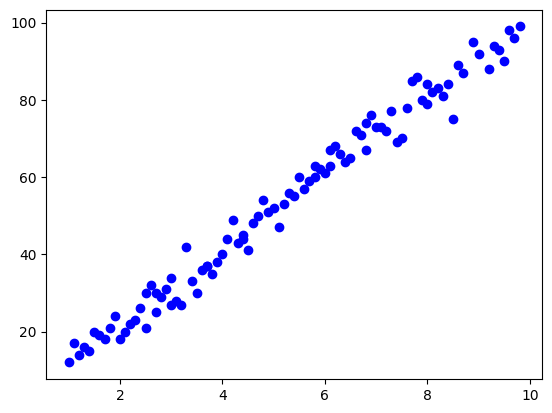

In [3]:
plt.scatter(df['Hours'], df['Scores'], color='blue')

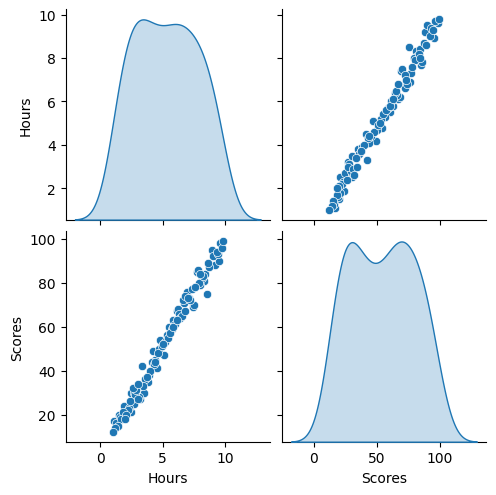

In [4]:
sns.pairplot(df, diag_kind='kde')

In [5]:
sns.set(style="whitegrid")

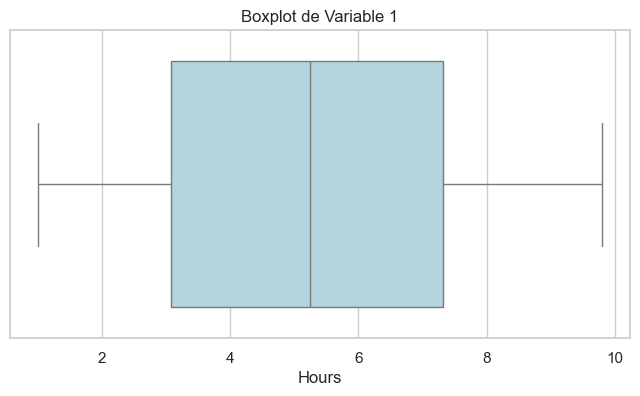

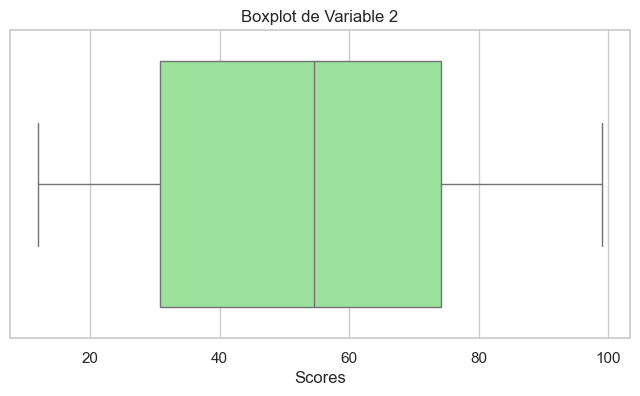

In [7]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Hours'], color='lightblue')
plt.title('Boxplot de Variable 1')
plt.xlabel('Hours')
plt.show()

# Boxplot de variable2
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Scores'], color='lightgreen')
plt.title('Boxplot de Variable 2')
plt.xlabel('Scores')
plt.show()

### **Parte 2: Ajuste del Modelo y Evaluación**
1. Ajustar una **regresión lineal** usando `statsmodels`.  
2. Interpretar los coeficientes del modelo y el **summary()**:
   - ¿Cuál es el valor de **R²**? ¿Qué indica sobre el modelo?  
   - ¿Los coeficientes son estadísticamente significativos?  
   - ¿Cómo interpretamos el coeficiente de la variable "horas de estudio"?  

3. Verificar los supuestos de la regresión lineal:
   - **Linealidad:** ¿La relación entre las variables parece una línea recta?  
   - **Normalidad de los residuos:** Graficar un **histograma de los residuos** y realizar un **test de normalidad**.  
   - **Homoscedasticidad:** Generar un **gráfico de residuos vs valores ajustados**.  
4. Responder: ¿Es apropiado un modelo de regresión lineal en este caso? ¿Por qué?  


---


In [5]:
# Ajuste del modelo
X = sm.add_constant(df['Hours'])  # Agrega el intercepto
model = sm.OLS(df['Scores'], X).fit()
# Resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Scores   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     4951.
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           4.18e-83
Time:                        19:55:49   Log-Likelihood:                -253.62
No. Observations:                  96   AIC:                             511.2
Df Residuals:                      94   BIC:                             516.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8636      0.820      2.273      0.0

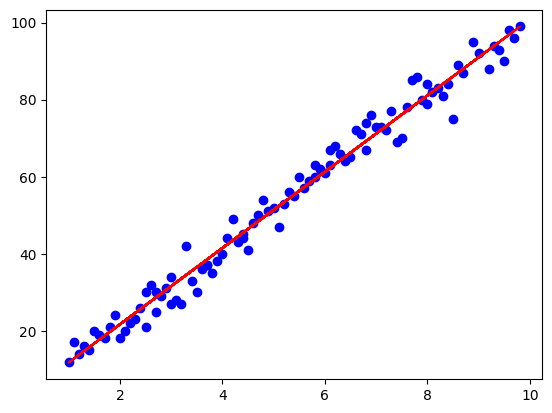

In [6]:
[theta_0_h,theta_1_h]=model.params
# Visualizar los datos y la línea de regresión con los parámetros estimados
plt.scatter(df['Hours'], df['Scores'], color='blue')
plt.plot(df['Hours'], theta_0_h + theta_1_h * df['Hours'], color='red')

verificar supuestos

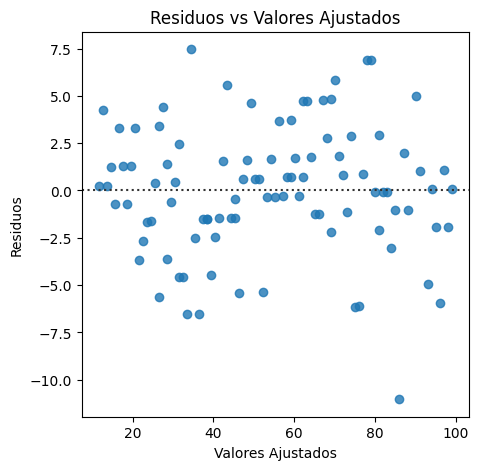

In [7]:
# Gráficos de diagnóstico
residuals = model.resid
fitted = model.fittedvalues
# Gráfico de residuos vs valores ajustados
plt.figure(figsize=(5, 5))
sns.residplot(x=fitted, y=residuals)
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores Ajustados')
plt.show()

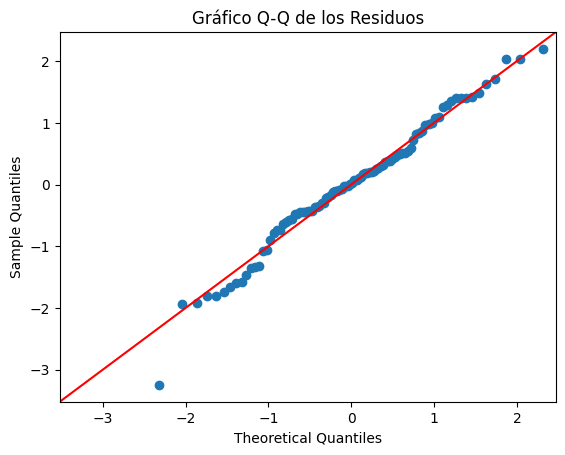

In [8]:
# Gráfico Q-Q
sm.qqplot(residuals, line='45', fit=True)
plt.title('Gráfico Q-Q de los Residuos')
plt.show()


### **Parte 3: Evaluación del Modelo con RMSE**
1. Calcular el **RMSE**.  
2. Reflexionar:  
   - ¿El RMSE es bajo o alto?  
   - ¿Qué indica esto sobre la precisión del modelo?  
   - ¿Cómo podríamos mejorar la predicción?  

---


In [9]:
mse = np.mean((df['Scores'] - fitted) ** 2)
print("Error cuadrático medio (MSE):", mse)

from sklearn.metrics import mean_squared_error
mean_squared_error(df['Scores'], fitted)

Error cuadrático medio (MSE): 11.54021082950942


11.54021082950942

In [49]:
RMSE = np.sqrt(mean_squared_error(df['Scores'], fitted))
RMSE

np.float64(3.3970885813457117)

### **Parte 4: Introducción de Valores Atípicos**  

1. **Modificar el dataset manualmente**, agregando al menos **tres puntos extremos**, por ejemplo:  
   - Un estudiante con **50 horas de estudio** pero una calificación de **30**.  
   - Un estudiante con **0 horas de estudio** pero una calificación de **95**.  
   - Un estudiante con **100 horas de estudio** y una calificación de **10**.  
2. **Visualizar nuevamente los datos** con los valores atípicos en un gráfico de dispersión.  




In [10]:
nuevos_puntos = pd.DataFrame({
    'Hours':  [50, 0, 100],
    'Scores': [30, 95, 10]
})

df = pd.concat([df, nuevos_puntos], ignore_index=True)
df

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
...,...,...
94,3.7,37
95,8.0,84
96,50.0,30
97,0.0,95


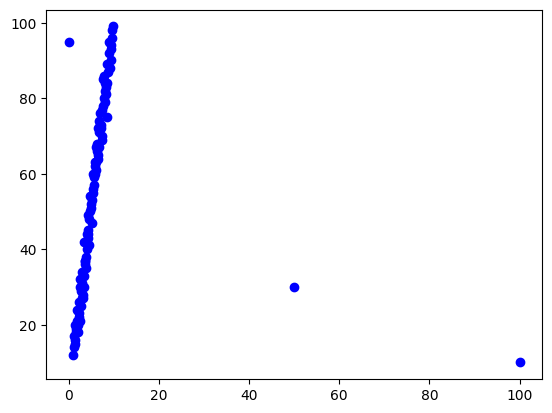

In [11]:
plt.scatter(df['Hours'], df['Scores'], color='blue')

---

### **Parte 5: Reevaluación del Modelo**  

1. **Volver a ajustar la regresión lineal** con los datos modificados.  
2. **Comparar los coeficientes y métricas** antes y después de agregar los valores atípicos:  
   - ¿Cómo cambiaron los coeficientes de la regresión?  
   - ¿El valor de R² aumentó o disminuyó? ¿Por qué?  
   - ¿Cómo cambió el RMSE?  
   - ¿Qué efectos observas en la línea de regresión en la gráfica?  
3. **Reflexionar**:  
   - ¿Cómo afectan los valores atípicos la precisión del modelo?  
   - ¿Qué podríamos hacer para mitigar su impacto?  
   - ¿Cuándo es recomendable eliminarlos y cuándo es mejor dejarlos en el análisis?  


In [12]:
# Ajuste del modelo
X = sm.add_constant(df['Hours'])  # Agrega el intercepto
model = sm.OLS(df['Scores'], X).fit()
# Resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Scores   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.02941
Date:                Mon, 09 Feb 2026   Prob (F-statistic):              0.864
Time:                        19:56:09   Log-Likelihood:                -460.52
No. Observations:                  99   AIC:                             925.0
Df Residuals:                      97   BIC:                             930.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         53.4752      3.024     17.682      0.0

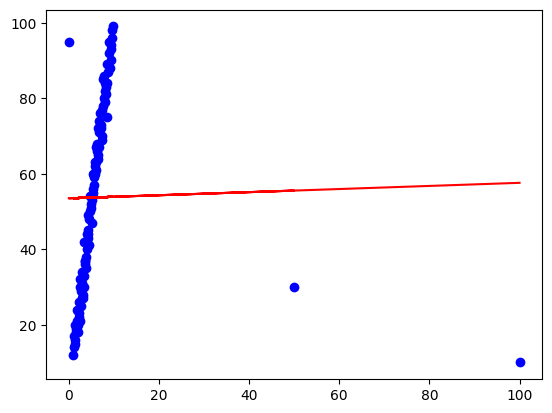

In [13]:
[theta_0_h,theta_1_h]=model.params
# Visualizar los datos y la línea de regresión con los parámetros estimados
plt.scatter(df['Hours'], df['Scores'], color='blue')
plt.plot(df['Hours'], theta_0_h + theta_1_h * df['Hours'], color='red')

In [57]:
y_hat = model.predict(X)
y_hat

0     53.577983
1     53.684860
2     53.606758
3     53.824622
4     53.619090
        ...    
94    53.627311
95    53.804069
96    55.530542
97    53.475217
98    57.585868
Length: 99, dtype: float64

In [56]:
fitted = model.fittedvalues
fitted

0     53.577983
1     53.684860
2     53.606758
3     53.824622
4     53.619090
        ...    
94    53.627311
95    53.804069
96    55.530542
97    53.475217
98    57.585868
Length: 99, dtype: float64

In [59]:
df['Scores']

0     21
1     47
2     27
3     75
4     30
      ..
94    37
95    84
96    30
97    95
98    10
Name: Scores, Length: 99, dtype: int64

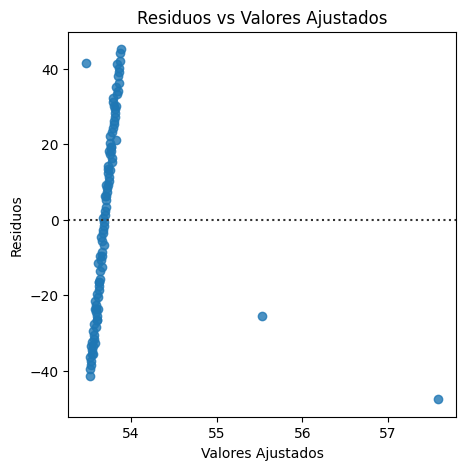

In [14]:
# Gráficos de diagnóstico
residuals = model.resid
fitted = model.fittedvalues
# Gráfico de residuos vs valores ajustados
plt.figure(figsize=(5, 5))
sns.residplot(x=fitted, y=residuals)
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores Ajustados')
plt.show()

In [60]:
model.params

const    53.475217
Hours     0.041107
dtype: float64

In [63]:
# Gráficos de diagnóstico
residuals = model.resid
fitted = model.fittedvalues
mse = np.mean((df['Scores'] - y_hat) ** 2)
print("Error cuadrático medio (MSE):", mse)
rmse = np.sqrt(mse)

Error cuadrático medio (MSE): 642.6807714440793


In [64]:
rmse

np.float64(25.351149312093906)

In [ ]:
from sklearn.metrics import mean_squared_error
MSE = mean_squared_error(df['Scores'], fitted)


## **Caso 2: Temperatura y Ventas de Helado (Relación No Lineal)**

📂 **Dataset:** `Ice_cream_selling_data.csv`  
📊 **Relación esperada:** No lineal  

### **Parte 1: Exploración de Datos y Supuestos**
1. Cargar los datos y visualizar la relación mediante un **gráfico de dispersión**.  
2. Evaluar la distribución de las variables usando histogramas y boxplots.
3. Responder: ¿Consideras que el modelo lineal es adecuado en este caso?  

---




In [23]:
import seaborn as sns
# 
df = pd.read_csv('data/Ice_cream_selling_data.csv')
df.head(2)

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120


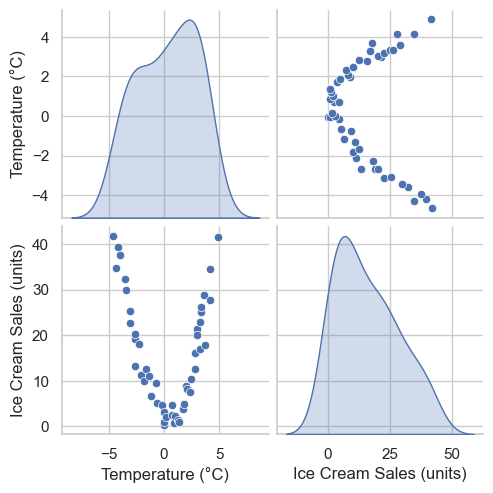

In [24]:
sns.pairplot(df, diag_kind='kde')


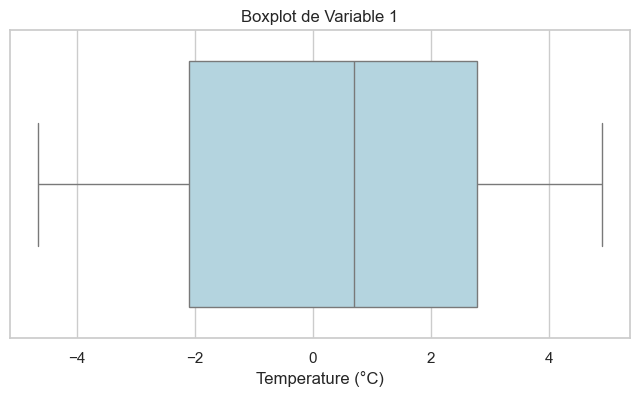

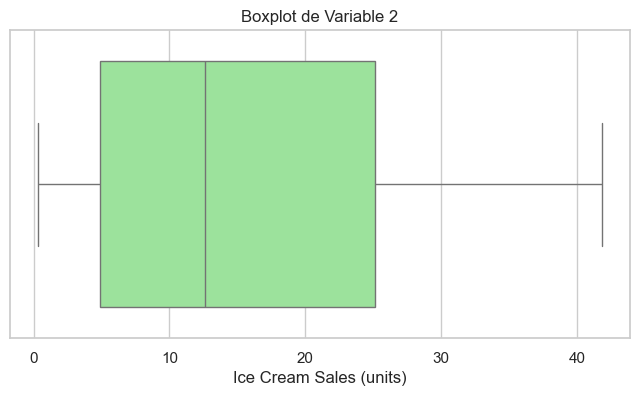

In [25]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Temperature (°C)'], color='lightblue')
plt.title('Boxplot de Variable 1')
plt.xlabel('Temperature (°C)')
plt.show()

# Boxplot de variable2
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Ice Cream Sales (units)'], color='lightgreen')
plt.title('Boxplot de Variable 2')
plt.xlabel('Ice Cream Sales (units)')
plt.show()

### **Parte 2: Ajuste del Modelo y Evaluación**
1. Ajustar una **regresión lineal** usando `statsmodels`.  
2. Interpretar los coeficientes del modelo y el **summary()**:
   - ¿Cuál es el valor de **R²**? ¿Qué indica sobre el modelo?  
   - ¿Los coeficientes son estadísticamente significativos?  
   - ¿Cómo interpretamos el coeficiente de la variable "temperatura"?

3. Verificar los supuestos de la regresión lineal:
   - **Linealidad:** ¿La relación entre las variables parece una línea recta?  
   - **Normalidad de los residuos:** Graficar un **histograma de los residuos** y realizar un **test de normalidad**.  
   - **Homoscedasticidad:** Generar un **gráfico de residuos vs valores ajustados**.  


---

In [26]:
# Ajuste del modelo
X = sm.add_constant(df['Temperature (°C)'])  # Agrega el intercepto
model = sm.OLS(df['Ice Cream Sales (units)'], X).fit()
# Resumen del modelo
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     Ice Cream Sales (units)   R-squared:                       0.031
Model:                                 OLS   Adj. R-squared:                  0.010
Method:                      Least Squares   F-statistic:                     1.488
Date:                     Mon, 17 Mar 2025   Prob (F-statistic):              0.229
Time:                             21:35:35   Log-Likelihood:                -191.09
No. Observations:                       49   AIC:                             386.2
Df Residuals:                           47   BIC:                             390.0
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

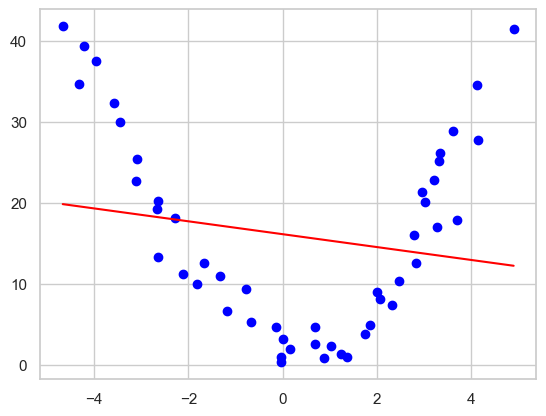

In [27]:
[theta_0_h,theta_1_h]=model.params
# Visualizar los datos y la línea de regresión con los parámetros estimados
plt.scatter(df['Temperature (°C)'], df['Ice Cream Sales (units)'], color='blue')
plt.plot(df['Temperature (°C)'], theta_0_h + theta_1_h * df['Temperature (°C)'], color='red')


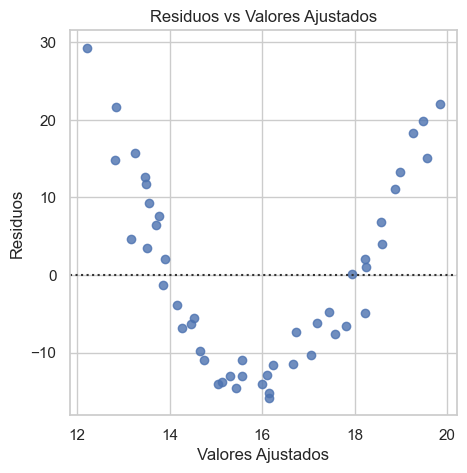

In [28]:

# Gráficos de diagnóstico
residuals = model.resid
fitted = model.fittedvalues
# Gráfico de residuos vs valores ajustados
plt.figure(figsize=(5, 5))
sns.residplot(x=fitted, y=residuals)
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores Ajustados')
plt.show()

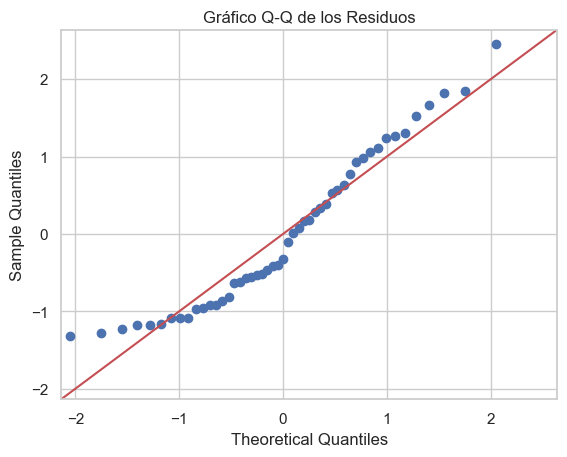

In [29]:
# Gráfico Q-Q
sm.qqplot(residuals, line='45', fit=True)
plt.title('Gráfico Q-Q de los Residuos')
plt.show()

### **Parte 3: Evaluación del Modelo con RMSE**
1. Calcular el **RMSE**.  
2. Reflexionar:  
   - ¿Que podemos concluir al usar solamente el RMSE como medida de desempeño?  
   - ¿Es posible hacer ajustes para mejorar el modelo?  

---


In [31]:
mse = np.mean((df['Ice Cream Sales (units)'] - fitted) ** 2)
print("Error cuadrático medio (MSE):", mse)


Error cuadrático medio (MSE): 142.83040442368952


In [32]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000



## **Caso 3: Análisis de Enfermedades Cardíacas (Selección de Variables y Comparación de Modelos)**

📂 **Dataset:** `dataset_2190_cholesterol.csv`  
📊 **Objetivo:** Identificar variables clave y construir modelos predictivos  



---

## Dataset de Colesterol y Enfermedad Cardíaca

Este dataset corresponde a una **colección clásica de bases de datos médicas** utilizadas para el estudio y diagnóstico de **enfermedad cardíaca**, y es ampliamente empleado en **ciencia de datos, estadística y aprendizaje automático**. En ciertos trabajos (por ejemplo, Kilpatrick & Cameron-Jones, 1998), el **nivel de colesterol sérico (`chol`) se utiliza como atributo objetivo**, permitiendo abordar el problema como **predicción numérica (regresión)**.

---

### Importancia del dataset

El dataset es relevante porque:

* Contiene **datos clínicos reales** de pacientes cardíacos.
* Permite analizar la relación entre **factores de riesgo cardiovascular** (edad, sexo, presión arterial, colesterol, ECG, etc.).
* Ha sido usado como **referencia histórica** para evaluar algoritmos de clasificación y predicción numérica, con resultados cercanos al **77–80% de precisión** en distintos estudios.

---

### Origen de los datos

Los datos fueron recolectados en cuatro instituciones médicas:

* Cleveland Clinic Foundation (EE. UU.)
* Hungarian Institute of Cardiology, Budapest
* V.A. Medical Center, Long Beach, California
* University Hospital, Zurich, Suiza

**Investigadores responsables:**

* Andras Janosi, M.D.
* William Steinbrunn, M.D.
* Matthias Pfisterer, M.D.
* Robert Detrano, M.D., Ph.D.

**Donante:** David W. Aha
**Fecha:** Julio de 1988

Los datos personales identificables fueron eliminados o reemplazados para proteger la privacidad.

---

### Tamaño y estructura

* **Número total de instancias:**

  * **Cleveland: 303**
  * Hungarian: 294
  * Switzerland: 123
  * Long Beach VA: 200

* **Número total de atributos:** 76

* **Atributos utilizados habitualmente:** 14 (todos numéricos)

La base de datos de **Cleveland** es la más usada en investigación y docencia.

---

### Tipo de datos

El dataset incluye variables:

* **Demográficas:** edad (`age`), sexo (`sex`)
* **Clínicas:** presión arterial en reposo (`trestbps`), **colesterol sérico (`chol`)**, glucosa en ayunas (`fbs`)
* **Resultados de pruebas cardíacas:** ECG (`restecg`), frecuencia cardíaca máxima (`thalach`), angina inducida por ejercicio (`exang`)
* **Indicadores diagnósticos:** número de vasos afectados (`ca`), prueba de talio (`thal`)

Según el enfoque del estudio:

* `chol` puede ser la **variable objetivo** (predicción numérica).
* `num` puede usarse como **variable objetivo**, indicando la presencia o severidad de enfermedad cardíaca (0–4), a menudo simplificada a presencia/ausencia.

---

### Valores faltantes

Existen valores faltantes lo que hace al dataset adecuado para prácticas de:

* Preprocesamiento
* Limpieza de datos
* Manejo de datos incompletos

---

### Tareas que se pueden realizar

Con este dataset se pueden abordar:

* **Análisis exploratorio de datos**
* **Predicción numérica** (por ejemplo, nivel de colesterol)
* **Clasificación** (presencia de enfermedad cardíaca)
* **Comparación de algoritmos** de machine learning
* **Aplicaciones reales en salud**, con discusión ética y clínica


### 🌍 Acceso

Dataset disponible públicamente: https://www.kaggle.com/datasets/mathurinache/cholesterol?resource=download



### **Parte 1: Identificación de Variables**
1. Cargar el dataset y explorar sus columnas.  
2. Identificar la **variable objetivo** (num: presencia de enfermedad cardíaca).  
3. Calcular la **correlación** de todas las variables con "num" y ordenarlas de mayor a menor.  

---


In [68]:
df = pd.read_csv('data/dataset_2190_cholesterol.csv')
df.head(2)

,age,sex,cp,trestbps,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,chol
0,63,1,1,145,1,2,150,0,2.3,3,0,6,0,233
1,67,1,4,160,0,2,108,1,1.5,2,3,3,2,286


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   fbs       303 non-null    int64  
 5   restecg   303 non-null    int64  
 6   thalach   303 non-null    int64  
 7   exang     303 non-null    int64  
 8   oldpeak   303 non-null    float64
 9   slope     303 non-null    int64  
 10  ca        303 non-null    object 
 11  thal      303 non-null    object 
 12  num       303 non-null    int64  
 13  chol      303 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 33.3+ KB


In [70]:
#hay un caracter ?, debemos reemplazarlo por nan
[df["ca"].unique(), 
 df["thal"].unique()]

[array(['0', '3', '2', '1', '?'], dtype=object),
 array(['6', '3', '7', '?'], dtype=object)]

In [71]:
#cuantos ? hay?
[df["ca"].value_counts(), 
 df["thal"].value_counts()]

[ca
 0    176
 1     65
 2     38
 3     20
 ?      4
 Name: count, dtype: int64,
 thal
 3    166
 7    117
 6     18
 ?      2
 Name: count, dtype: int64]

In [72]:
# Reemplazamos '?' por NaN temporalmente para trabajar mejor
df['ca'] = df['ca'].replace('?', pd.NA)
# Convertimos los valores a numéricos (automáticamente va a ignorar el NaN)
df['ca'] = pd.to_numeric(df['ca'], errors='coerce')
# Calculamos la moda (valor que más se repite)
moda = df['ca'].mode()[0]
#Imputamos los valores faltantes (NaN) por la moda:
df['ca'] = df['ca'].fillna(moda)

In [73]:
# LO MISMO EN thal
df['thal'] = df['thal'].replace('?', pd.NA)
# 
df['thal'] = pd.to_numeric(df['thal'], errors='coerce')
# 
moda = df['thal'].mode()[0]
#
df['thal'] = df['thal'].fillna(moda)

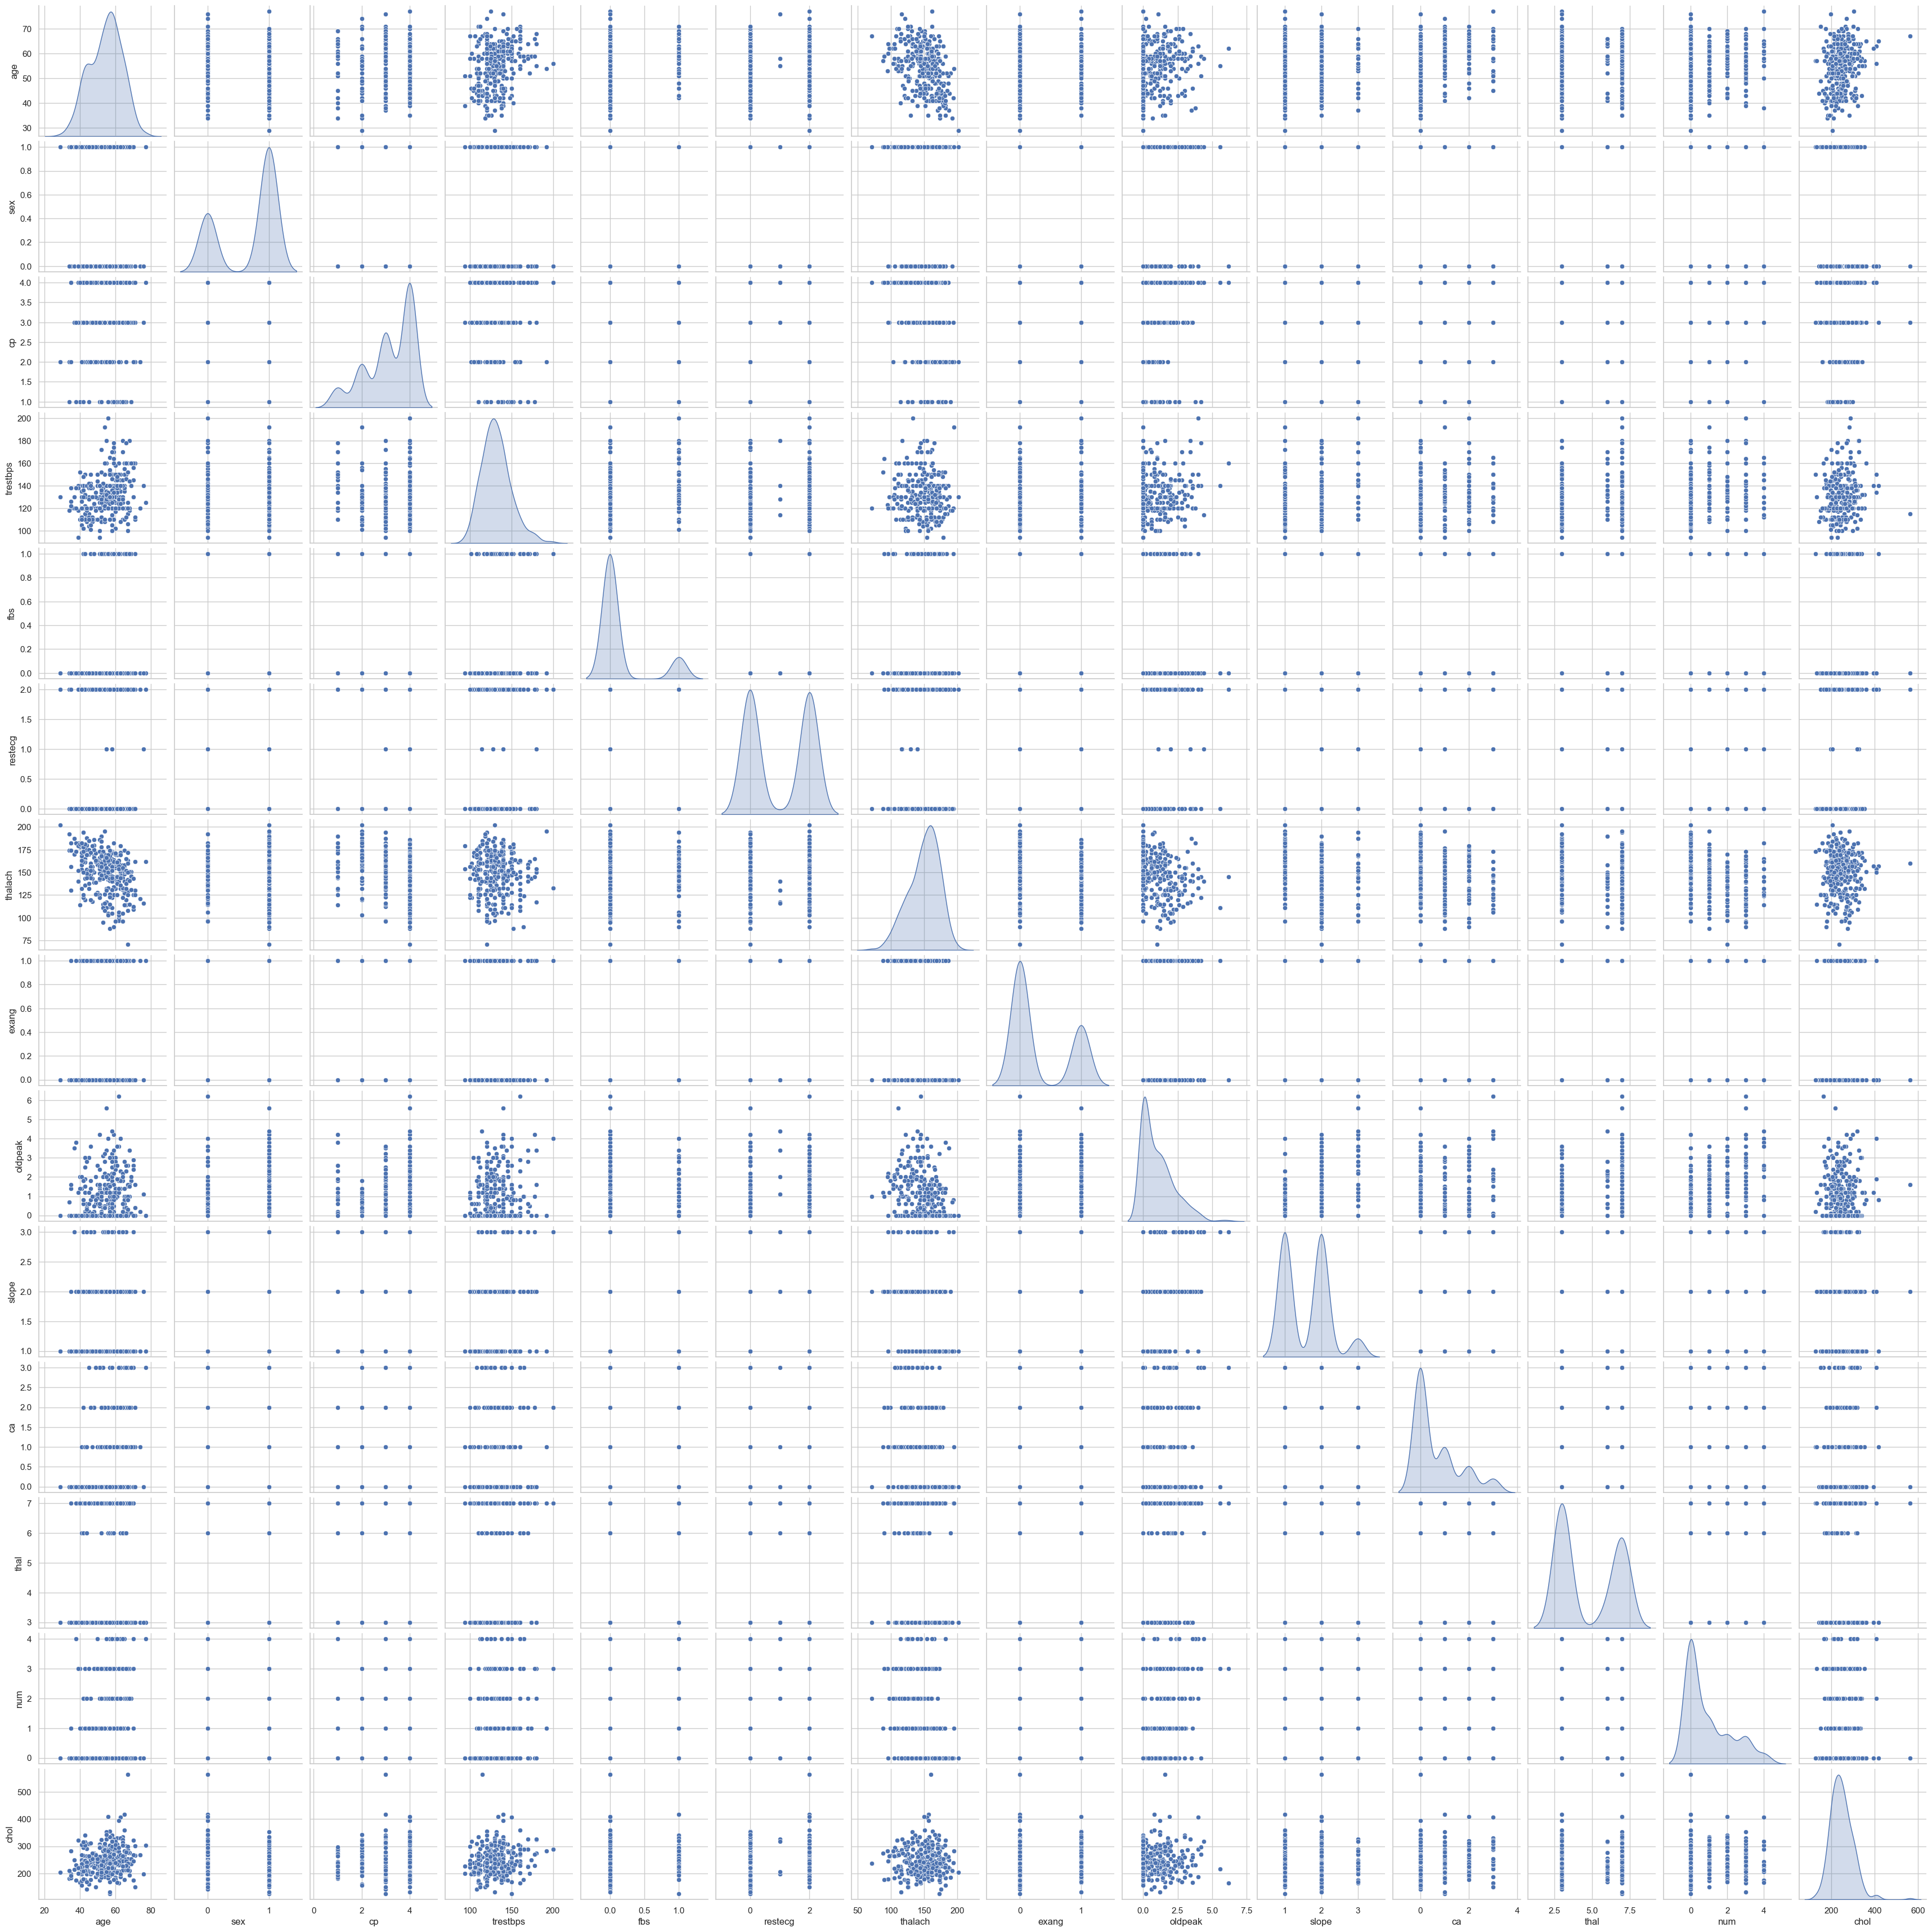

In [74]:
sns.pairplot(df, diag_kind='kde')

In [75]:
correlation_matrix = df.corr()
# Filtra la correlación de las variables predictoras con la variable objetivo "num"
correlation_with_target = correlation_matrix[['num']].drop('num').abs()
# Mostrar el dataframe de correlaciones ordenadas
correlation_sorted = correlation_with_target.sort_values(by=["num"],ascending=False)

print(correlation_sorted)


               num
ca        0.520968
thal      0.507155
oldpeak   0.504092
thalach   0.415040
cp        0.407075
exang     0.397057
slope     0.377957
sex       0.224469
age       0.222853
restecg   0.183696
trestbps  0.157754
chol      0.070909
fbs       0.059186


### **Parte 2: Selección de Variables y Modelado**
1. Seleccionar las **tres variables con mayor correlación** con "num".  
2. Ajustar **tres modelos de regresión lineal** (uno para cada variable independiente).  
3. Evaluar los coeficientes y métricas del summary():
   - **R² ajustado**  
   - **Significancia de los coeficientes**  
     


In [83]:
# Ajuste del modelo
X = sm.add_constant(df['ca'])  # Agrega el intercepto
model1 = sm.OLS(df['num'], X).fit()
# Resumen del modelo
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    num   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     112.1
Date:                Tue, 18 Mar 2025   Prob (F-statistic):           1.76e-22
Time:                        06:58:50   Log-Likelihood:                -443.83
No. Observations:                 303   AIC:                             891.7
Df Residuals:                     301   BIC:                             899.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4829      0.074      6.522      0.0

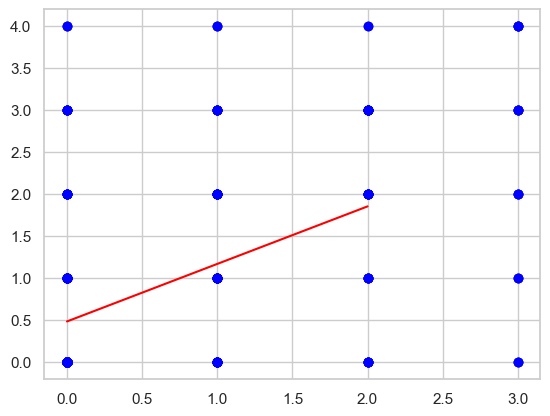

In [84]:
[theta_0_h,theta_1_h]=model1.params
# Visualizar los datos y la línea de regresión con los parámetros estimados
plt.scatter(df['ca'], df['num'], color='blue')
x = np.arange(df['ca'].min(), df['ca'].max())
plt.plot(x, theta_0_h + theta_1_h * x, color='red')


In [85]:
# Ajuste del modelo
X = sm.add_constant(df['thal'])  # Agrega el intercepto
model2 = sm.OLS(df['num'], X).fit()
# Resumen del modelo
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                    num   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     104.2
Date:                Tue, 18 Mar 2025   Prob (F-statistic):           3.30e-21
Time:                        06:59:00   Log-Likelihood:                -446.76
No. Observations:                 303   AIC:                             897.5
Df Residuals:                     301   BIC:                             904.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5808      0.161     -3.614      0.0

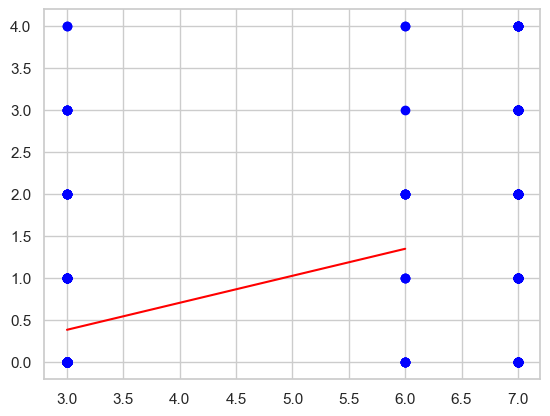

In [86]:
[theta_0_h,theta_1_h]=model2.params
# Visualizar los datos y la línea de regresión con los parámetros estimados
plt.scatter(df['thal'], df['num'], color='blue')
x = np.arange(df['thal'].min(), df['thal'].max())
plt.plot(x, theta_0_h + theta_1_h * x, color='red')

In [88]:
# Ajuste del modelo
X = sm.add_constant(df['oldpeak'])  # Agrega el intercepto
model3 = sm.OLS(df['num'], X).fit()
# Resumen del modelo
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    num   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     102.5
Date:                Tue, 18 Mar 2025   Prob (F-statistic):           6.21e-21
Time:                        06:59:13   Log-Likelihood:                -447.39
No. Observations:                 303   AIC:                             898.8
Df Residuals:                     301   BIC:                             906.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3828      0.082      4.667      0.0

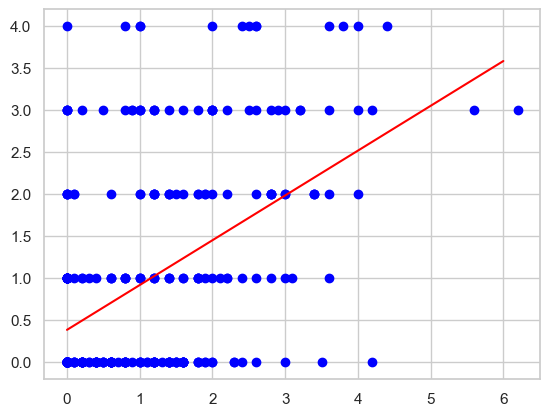

In [89]:
[theta_0_h,theta_1_h]=model3.params
# Visualizar los datos y la línea de regresión con los parámetros estimados
plt.scatter(df['oldpeak'], df['num'], color='blue')
x = np.arange(df['oldpeak'].min(), df['oldpeak'].max())
plt.plot(x, theta_0_h + theta_1_h * x, color='red')

---

### **Parte 3: Comparación y Conclusiones**
1. Comparar los modelos en términos de **desempeño predictivo**.  
2. Reflexionar:  
   - ¿Cuál de las tres variables tiene mayor poder predictivo?  
   - ¿Se podría mejorar el modelo combinando variables?  
   - ¿Qué conclusiones podemos extraer sobre el colesterol y las enfermedades cardíacas?  



In [92]:
fitted1 = model1.fittedvalues
mse = np.mean((df['num'] - fitted1) ** 2)
print("Error cuadrático medio (MSE) model1:", mse)

fitted2 = model2.fittedvalues
mse = np.mean((df['num'] - fitted2) ** 2)
print("Error cuadrático medio (MSE) model2:", mse)

fitted3 = model3.fittedvalues
mse = np.mean((df['num'] - fitted3) ** 2)
print("Error cuadrático medio (MSE) model3:", mse)

Error cuadrático medio (MSE) model1: 1.0960349771364668
Error cuadrático medio (MSE) model2: 1.1173991489510713
Error cuadrático medio (MSE) model3: 1.1220582410968263



---

## **Entrega y Discusión**
- Los estudiantes discutiran en la ultima parte de la clase sus análisis e interpretación de resultados y conclusiones.  
- Se discutirá en clase cómo mejorar los modelos y qué otras técnicas podrían aplicarse.  

---